In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('../data/processed/weather_clean.csv')
df.tail()

,city_address,city_latitude,city_longitude,day_datetime,day_tempmax,day_tempmin,day_temp,day_humidity,day_precip,day_windspeed,...,datetime_hour,hour,day_of_week,month,is_night,is_rain,is_snow,temp_diff,pressure_trend,season
808342,Zhytomyr,50.2536,28.6654,2026-03-15,12.0,-0.3,5.2,60.6,0.0,18.7,...,2026-03-15 20:00:00,20,6,3,0,0,0,1.9,0.3,2
808343,Zhytomyr,50.2536,28.6654,2026-03-15,12.0,-0.3,5.2,60.6,0.0,18.7,...,2026-03-15 21:00:00,21,6,3,0,0,0,2.0,0.3,2
808344,Zhytomyr,50.2536,28.6654,2026-03-15,12.0,-0.3,5.2,60.6,0.0,18.7,...,2026-03-15 22:00:00,22,6,3,1,0,0,2.1,1.3,2
808345,Zhytomyr,50.2536,28.6654,2026-03-15,12.0,-0.3,5.2,60.6,0.0,18.7,...,2026-03-15 23:00:00,23,6,3,1,0,0,1.8,1.3,2
808346,Zhytomyr,50.2536,28.6654,2026-03-16,11.7,-1.0,4.8,65.8,0.0,14.4,...,2026-03-16 00:00:00,0,0,3,1,0,0,1.4,2.0,2


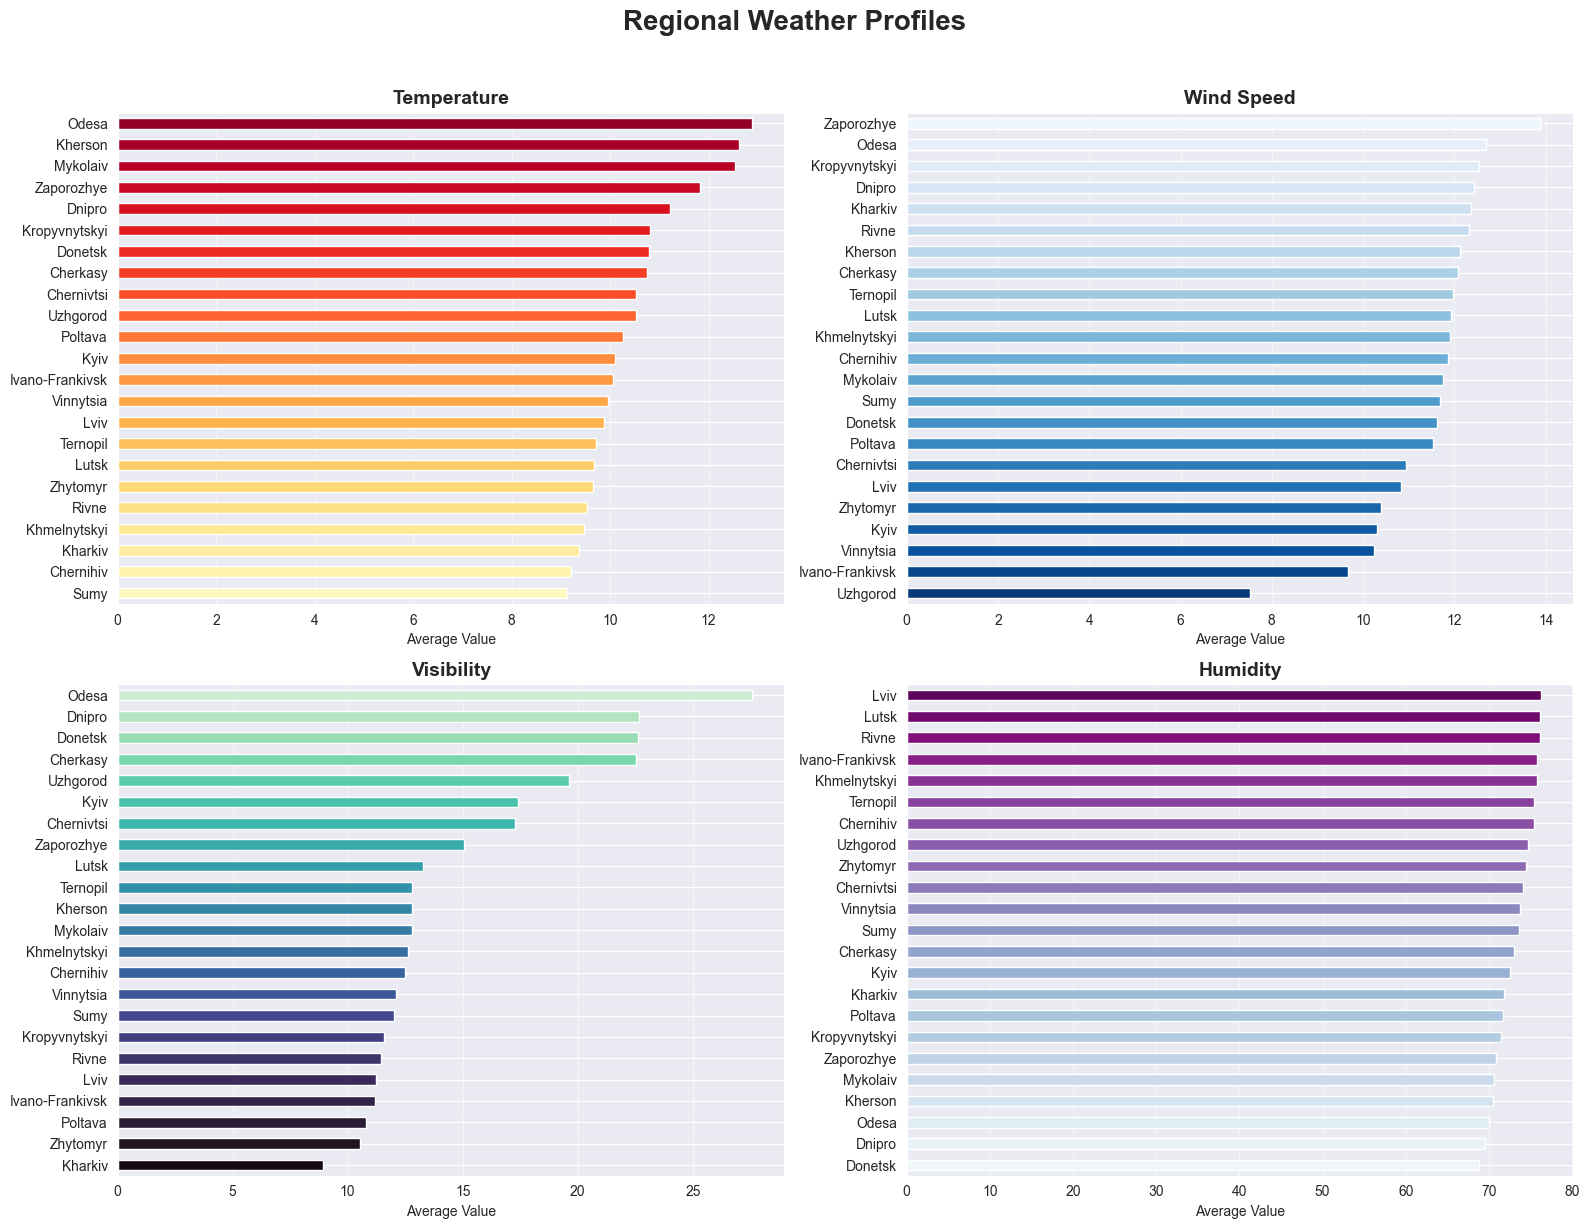

In [3]:
palettes = ["YlOrRd", "Blues_r", "mako", "BuPu"]
metrics = {'hour_temp': 'Temperature', 'hour_windspeed': 'Wind Speed', 'hour_visibility': 'Visibility', 'hour_humidity': 'Humidity'}
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
for i, (col, title) in enumerate(metrics.items()):
    data = df.groupby('city_address')[col].mean().sort_values()
    current_palette = sns.color_palette(palettes[i], len(data))
    data.plot(kind='barh', ax=axes[i], color=current_palette)
    axes[i].set_title(title, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Average Value')
    axes[i].set_ylabel('')
    axes[i].grid(axis='x', linestyle='--', alpha=0.7)
plt.suptitle('Regional Weather Profiles', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Regional Weather Profiles Analysis
* **Temperature**: Southern cities Odesa, Kherson and Mykolaiv lead in heat, while the North Sumy, Chernihiv and Kharkiv remains the coldest.
* **Wind Speed**: Highest in Zaporizhzhia and Odesa. Uzhhorod is the calmest due to its location.
* **Visibility**: Odesa shows the best clarity. Kharkiv and Zhytomyr have the lowest visibility levels.
* **Humidity**: Western cities Lviv, Lutsk peak at around 75-77%, while the South and East remain slightly lower, averaging near 70%.

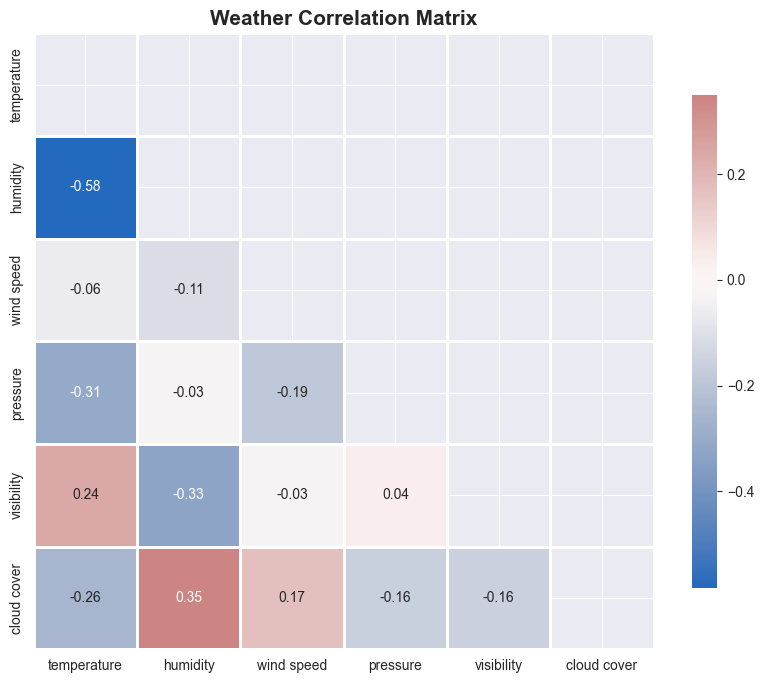

In [4]:
mapping = {'hour_temp': 'temperature', 'hour_humidity': 'humidity', 'hour_windspeed': 'wind speed',
           'hour_pressure': 'pressure', 'hour_visibility': 'visibility', 'hour_cloudcover': 'cloud cover'}
cols = ['hour_temp', 'hour_humidity', 'hour_windspeed', 'hour_pressure', 'hour_visibility', 'hour_cloudcover']
corr = df[cols].rename(columns=mapping).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='vlag', center=0, linewidths=1, linecolor='white', cbar_kws={"shrink": .8})
plt.title('Weather Correlation Matrix', fontsize=15, fontweight='bold')
plt.show()

# Statistical Correlation Analysis
* **Temperature and Humidity**: Show a strong negative correlation (-0.58).
* **Cloud cover and Humidity**: These parameters are positively correlated (0.35), cloudiness is often associated with higher humidity levels.
* **Visibility and Humidity**: Negative correlation (-0.33), high humidity levels tend to reduce visibility.
* **Temperature and Cloud cover**: Show a slight negative correlation (-0.26), as clear days are often warmer than overcast ones.
* **Temperature and Visibility**: Small positive correlation (0.24), warmer air can often lead to clearer skies.
* **Temperature and Pressure**: Negative correlation (-0.31)
* **Wind speed and Pressure**: Show a slight negative correlation
* **Pressure and Visibility**: show weak correlation (0.04)

# Hypothesis 1
A shorter daylight period increases electricity consumption. A significant decrease in temperature may lead to an increase in attacks on energy infrastructure facilities. This occurs because electricity consumption rises during colder periods, which may lead to a deficit in the energy system. As a result, the energy sector becomes more vulnerable to attacks.

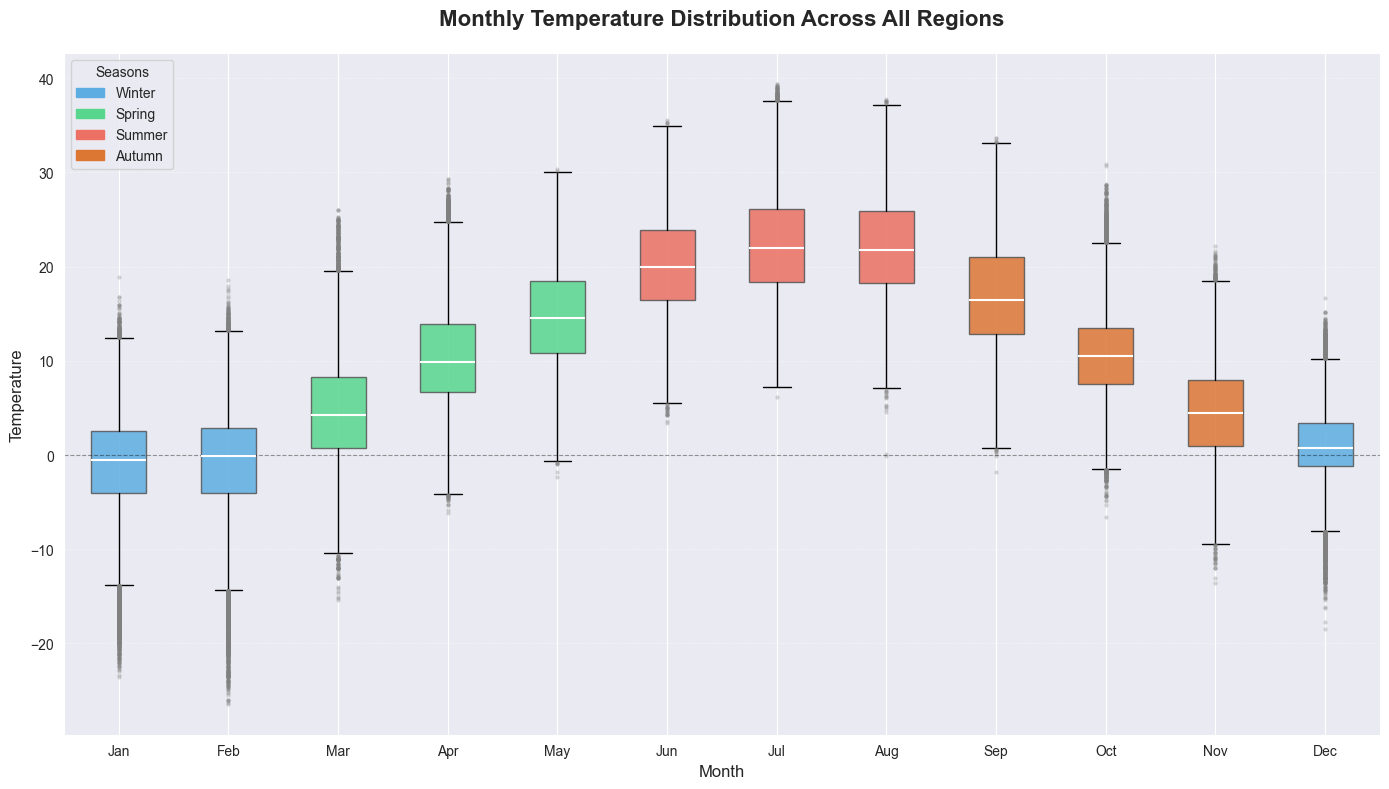

In [5]:
import matplotlib.patches as mpatches
seasons = {'Winter':  {'months': [12, 1, 2], 'color': '#5DADE2'},
                  'Spring': {'months': [3, 4, 5],  'color': '#58D68D'},
                  'Summer':  {'months': [6, 7, 8],  'color': '#EC7063'},
                  'Autumn': {'months': [9, 10, 11], 'color': '#DC7633'}}
month_order = list(range(1, 13))
month_names = ['Jan','Feb','Mar','Apr','May','Jun', 'Jul','Aug','Sep','Oct','Nov','Dec']
data = [df[df['month'] == m]['hour_temp'].dropna() for m in month_order]
plt.figure(figsize=(14, 8))
bp = plt.boxplot(data, patch_artist=True, medianprops=dict(color='white', linewidth=1.5),
                 flierprops=dict(marker='o', markersize=3, markerfacecolor='gray', alpha=0.3, markeredgecolor='none'))

for patch, m in zip(bp['boxes'], month_order):
    for season_name, config in seasons.items():
        if m in config['months']:
            patch.set_facecolor(config['color'])
            patch.set_edgecolor('#555555')
            patch.set_alpha(0.85)
            break
legend_handles = [mpatches.Patch(color=cfg['color'], label=name) for name, cfg in seasons.items()]
plt.legend(handles=legend_handles, title="Seasons", loc='upper left', frameon=True, fontsize=10)
plt.xticks(range(1, 13), month_names)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
plt.title('Monthly Temperature Distribution Across All Regions', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Temperature', fontsize=12)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Monthly temperature variations across Ukraine
## Seasonal trends
* **Winter (December-February)**: Medians are around 0 C. Wide lower whiskers and numerous outliers indicate frequent severe frosts, though most days stay between -5 C and +5 C.
* **Spring (March-May)**: A steady warming trend, with medians rising from +4 C to +15 C. Increased box height in March and May reflects high transitional variability.
* **Summer (June-August)**: Peak temperatures with medians between 20-22 C. Notable extremes range from unusual lows of +5 C to heatwaves reaching +40 C.
* **Autumn (September-November)**: Temperatures decline rapidly, with medians dropping from +17 C in September to +5 C by November.

# Hypothesis 2
Low visibility may indirectly affect the duration of air raid alerts. In winter, low visibility occurs more frequently because at low temperatures the air reaches the dew point faster, which leads to more frequent fog and precipitation. The relationship between temperature and visibility is supported by the correlation matrix graph that shows correlations between different weather parameters.

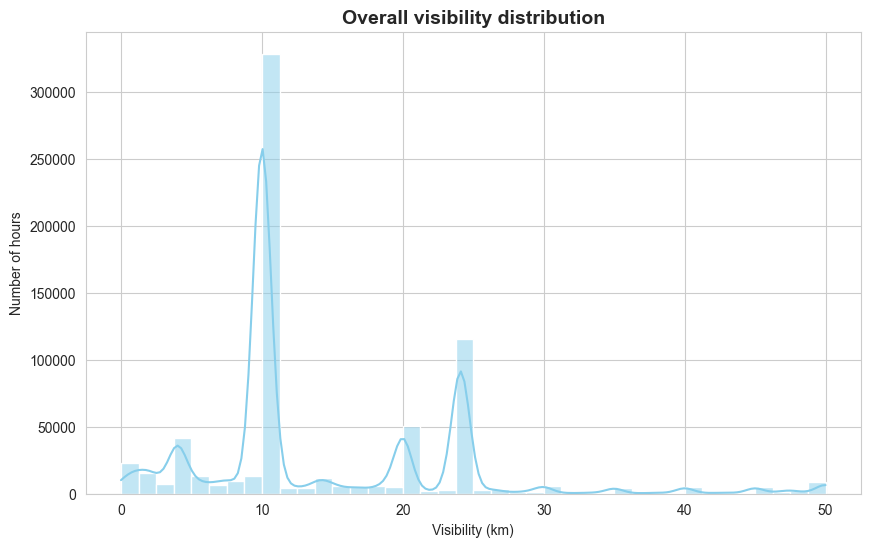

In [6]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.histplot(df['hour_visibility'], bins=40, color='skyblue', kde=True)
plt.title('Overall visibility distribution', fontsize=14, fontweight='bold')
plt.xlabel('Visibility (km)')
plt.ylabel('Number of hours')
plt.show()

# Visibility analysis
Visibility is generally high, with a primary peak at 10 km and a secondary concentration between 20-25 km. Instances of critically low visibility are rare.

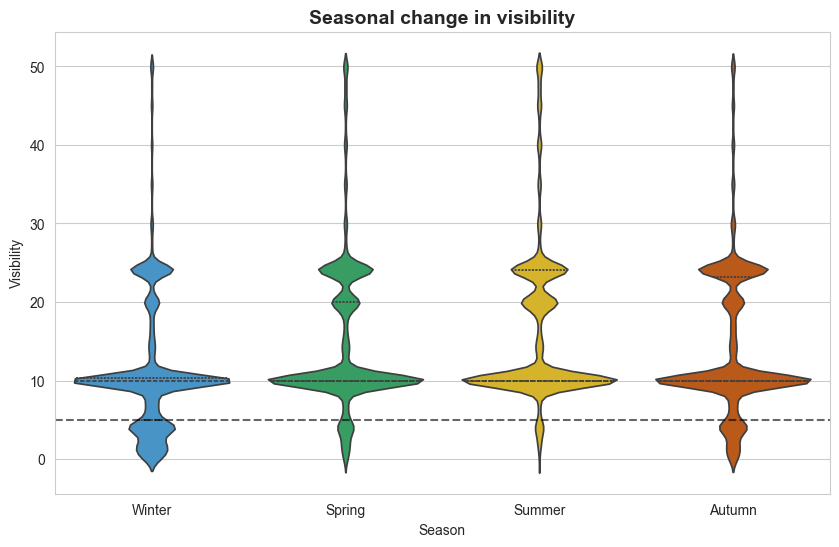

In [7]:
season_map = {1: 'Winter', 2: 'Spring', 3: 'Summer', 4: 'Autumn'}
df['season_name'] = df['season'].map(lambda s: season_map.get(s, s))
plt.figure(figsize=(10, 6))
palette = {'Winter': '#3498db', 'Spring': '#27ae60', 'Summer': '#f1c40f', 'Autumn': '#d35400'}
sns.violinplot(data=df, x='season_name', y='hour_visibility', hue='season_name', palette=palette, legend=False,order=['Winter', 'Spring', 'Summer', 'Autumn'], inner="quartile")
plt.axhline(5, color='black', linestyle='--', alpha=0.6)
plt.title('Seasonal change in visibility', fontsize=14, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Visibility')
plt.show()

# Seasonal trends in visibility
The violin plots show that visibility is most frequently concentrated around 10 km across all seasons.
* **Winter**: Shows the most significant density in the lower range, indicating that low visibility events are most frequent during this season.
* **Spring and Autumn**: Both show noticeable expansion at lower levels, suggesting a higher probability of poor visibility compared to summer.
* **Summer**: Features the smallest lower tail representing the best overall visibility conditions and the most stable clear sky conditions among all seasons.

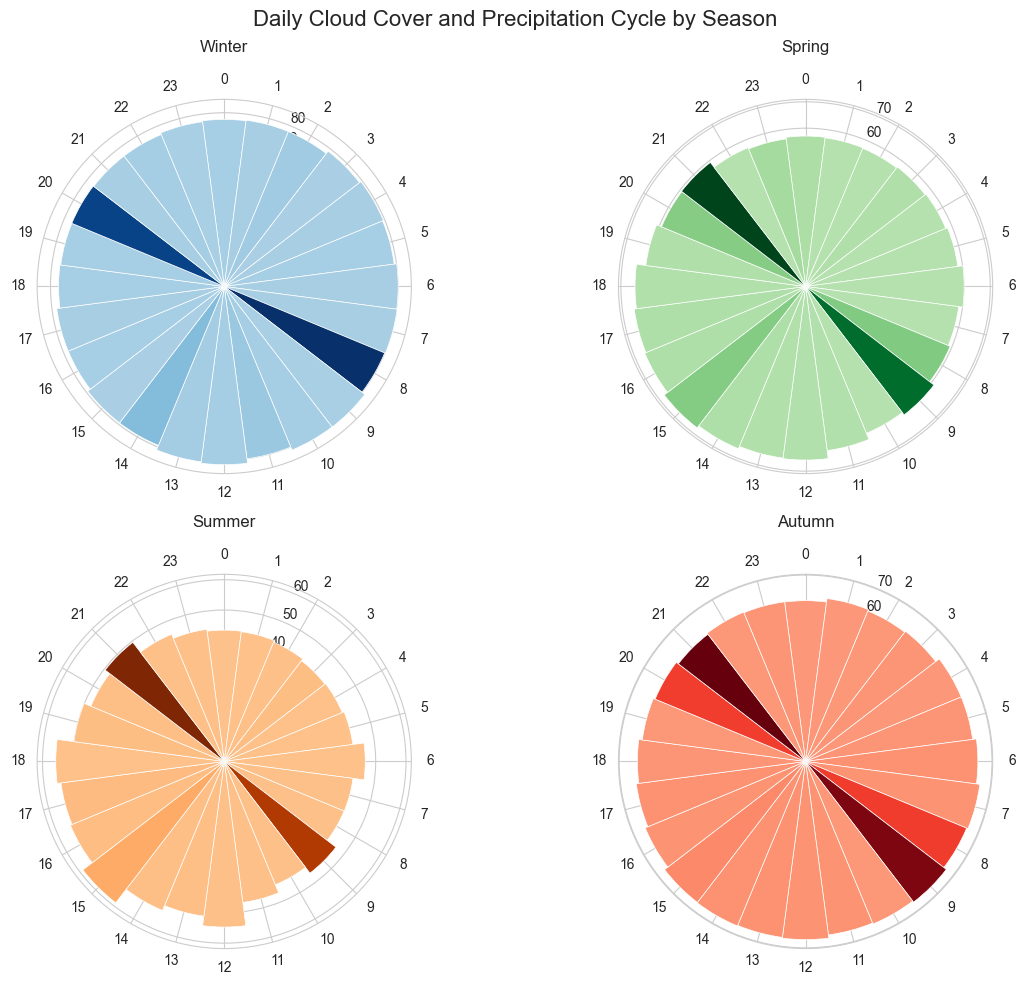

In [8]:
season_names = {1: 'Winter', 2: 'Spring', 3: 'Summer', 4: 'Autumn'}
season_cmaps = {1: plt.get_cmap('Blues'), 2: plt.get_cmap('Greens'), 3: plt.get_cmap('Oranges'), 4: plt.get_cmap('Reds')}
fig, axes = plt.subplots(2, 2, figsize=(12,10), subplot_kw={'projection':'polar'})
axes = axes.flatten()
for i, season in enumerate([1, 2, 3, 4]):
    seasonal = df[df['season'] == season]
    hourly = seasonal.groupby('hour')[['hour_cloudcover','hour_precip']].mean().reset_index()
    theta = np.linspace(0, 2*np.pi, 24, endpoint=False)
    radii = hourly['hour_cloudcover']
    precip_max = hourly['hour_precip'].max()
    precip_norm = hourly['hour_precip'] / (precip_max + 1e-9)
    colors = season_cmaps[season](0.3 + 0.7 * precip_norm)
    axes[i].bar(theta, radii, width=2*np.pi/24, color=colors, edgecolor='white', linewidth=0.5)
    axes[i].set_theta_zero_location('N')
    axes[i].set_theta_direction(-1)
    axes[i].set_xticks(theta)
    axes[i].set_xticklabels(range(24))
    axes[i].set_title(season_names[season], pad=15)
plt.suptitle('Daily Cloud Cover and Precipitation Cycle by Season', fontsize=16)
plt.tight_layout()
plt.show()

## Cloud Cover Radial Depth
* **Winter**: Has the highest cloud cover level.
* **Summer**: Has the lowest cloud cover level and maximum sunshine hours.
* **Spring and Autumn**: These seasons have moderate levels of cloud cover and smoother transitions.
## Precipitation Color Intensity
* **Winter and Spring**: Have peaks in the morning **07:00-09:00** and evening **20:00-22:00**.
* **Summer**: Cloud cover slightly increases toward midday and afternoon but remains relatively moderate overall.
* **Autumn**: Show noticeable precipitation peaks, particularly in the morning around **08:00-09:00** and evening around **20:00-22:00**, but these precipitation peaks are not as sharp as in **Winter** and in **Spring**.
### Overall across all seasons morning and evening precipitation peaks can be observed.

 # Hypothesis 3
Wind direction allows the identification of dominant air flows in different regions. Together with wind speed and wind gusts, these factors may influence the trajectory, speed, and stability of unmanned aerial vehicles. Strong or unstable winds may potentially alter the movement characteristics of aerial targets, directly affecting the probability of an air raid alert occurring in a given region.

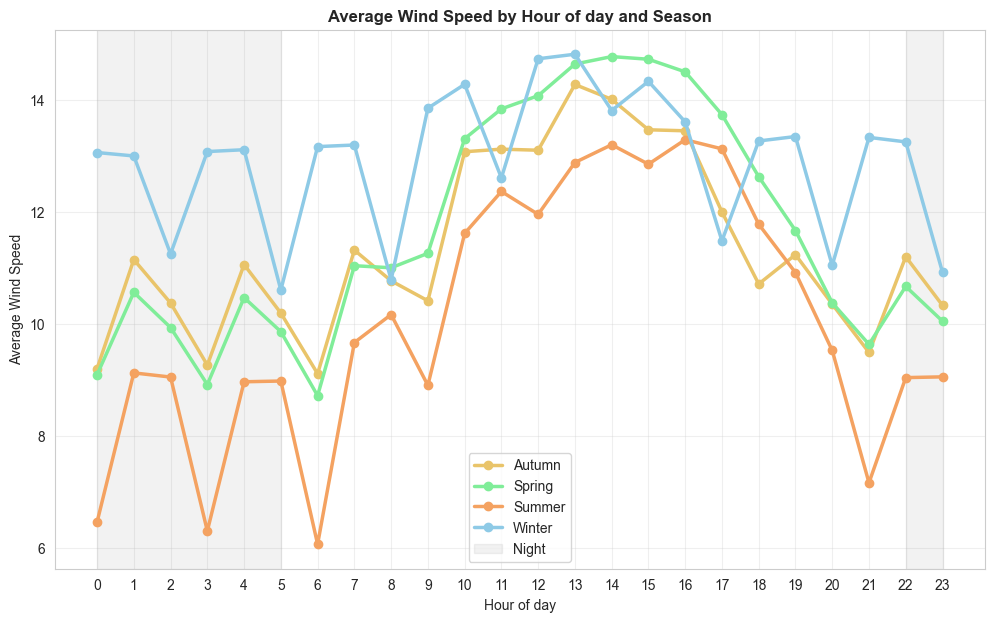

In [9]:
season_map = {1: 'Winter', 2: 'Spring', 3: 'Summer', 4: 'Autumn'}
df['season_name'] = df['season'].map(season_map)
df_aggr = df.groupby(['hour', 'season_name'])['hour_windspeed'].mean().unstack()
plt.figure(figsize=(12,7))
colors = {'Winter': '#8ECAE6', 'Spring': '#80ED99', 'Summer': '#F4A261', 'Autumn': '#E9C46A'}
for season in df_aggr.columns:
    plt.plot(df_aggr.index, df_aggr[season], label=season, color=colors.get(season, 'gray'), marker='o', linewidth=2.5)
plt.axvspan(22, 23, color='gray', alpha=0.1, label='Night')
plt.axvspan(0, 5, color='gray', alpha=0.1)
plt.title('Average Wind Speed by Hour of day and Season', fontweight='bold')
plt.xlabel('Hour of day')
plt.ylabel('Average Wind Speed')
plt.xticks(range(24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# The diurnal cycles and seasonal variations in wind speed
* **Winter** maintains the highest baseline speeds during the night and early morning.
* **Spring** reaches the highest peaks during the afternoon hours **12:00-16:00**.
* **Summer** is consistently the least windy season.
* **Autumn** shows a moderate diurnal increase during daylight hours
 ***Wind speeds are not constant through the day***.

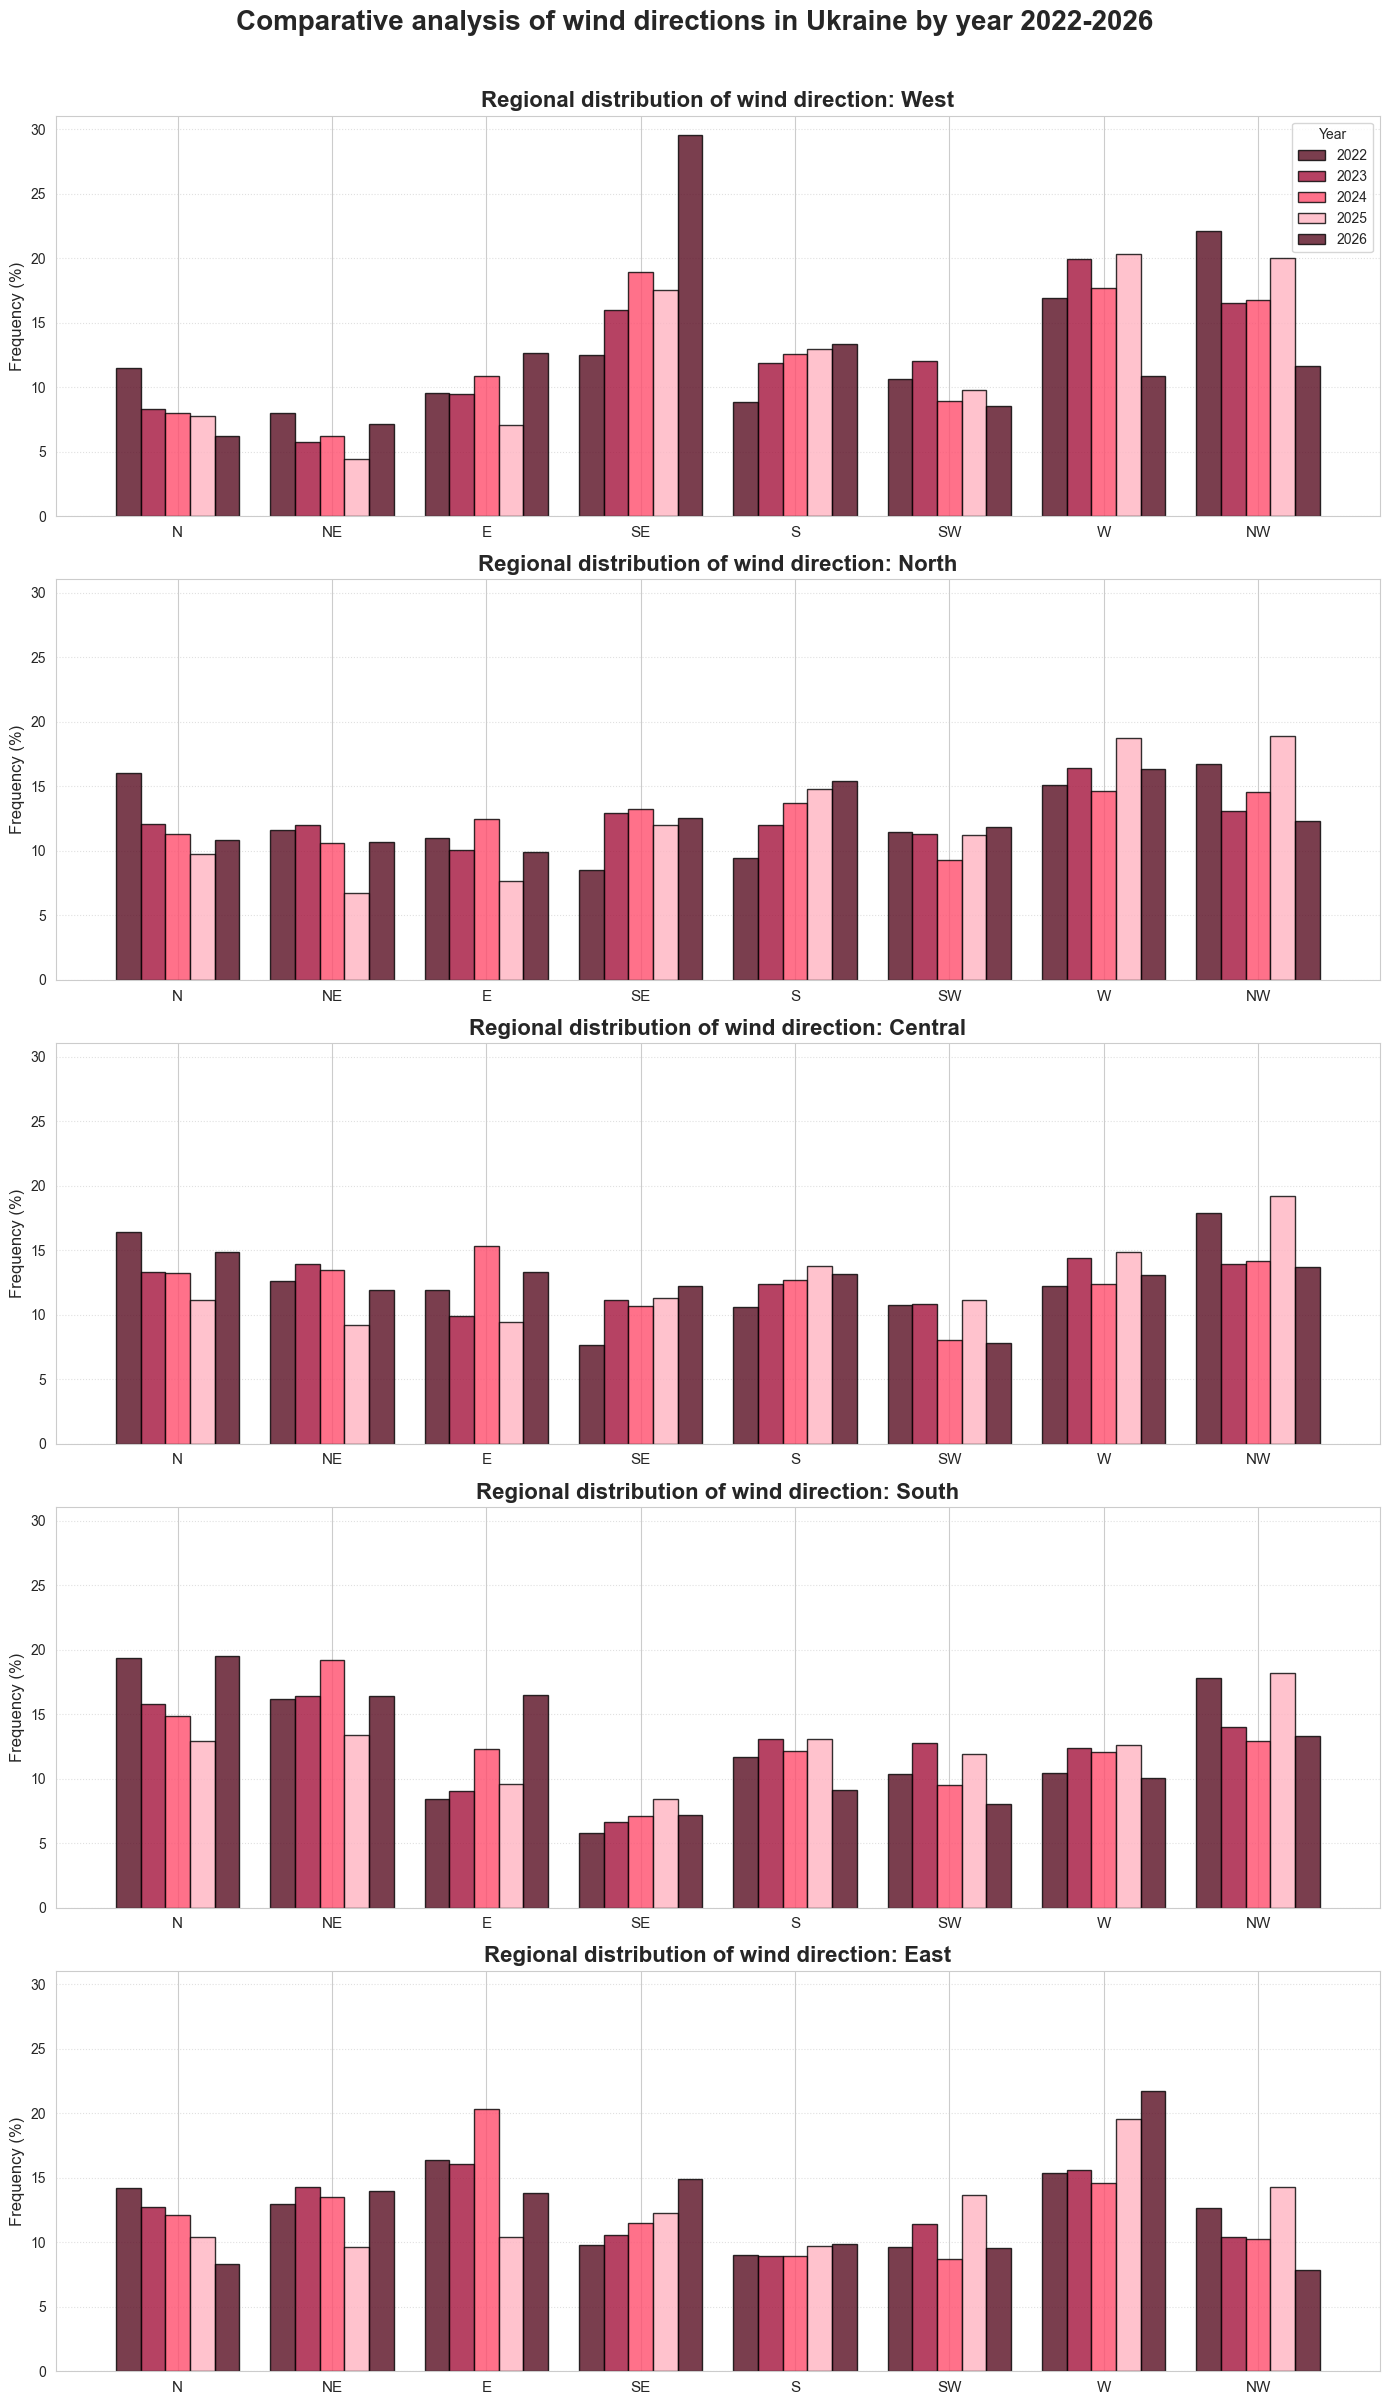

In [11]:
df['day_datetime'] = pd.to_datetime(df['day_datetime'])
df['year'] = df['day_datetime'].dt.year
regions_map = {'West': ['Lviv', 'Lutsk', 'Rivne', 'Ternopil', 'Ivano-Frankivsk', 'Uzhhorod', 'Chernivtsi'],
               'North': ['Kyiv', 'Chernihiv', 'Zhytomyr', 'Sumy'],
               'Central': ['Poltava', 'Cherkasy', 'Kropyvnytskyi', 'Vinnytsia', 'Dnipro'],
               'South': ['Odesa', 'Mykolaiv', 'Kherson', 'Zaporizhzhia'],
               'East': ['Kharkiv', 'Donetsk']}

def assign_region(city):
    for reg, cities in regions_map.items():
        if city in cities: return reg
    return 'Other'

df['region'] = df['city_address'].apply(assign_region)

def get_direction(deg):
    if pd.isna(deg): return 'N/A'
    if (deg >= 337.5) or (deg < 22.5): return 'N'
    if (deg >= 22.5) and (deg < 67.5): return 'NE'
    if (deg >= 67.5) and (deg < 112.5): return 'E'
    if (deg >= 112.5) and (deg < 157.5): return 'SE'
    if (deg >= 157.5) and (deg < 202.5): return 'S'
    if (deg >= 202.5) and (deg < 247.5): return 'SW'
    if (deg >= 247.5) and (deg < 292.5): return 'W'
    if (deg >= 292.5) and (deg < 337.5): return 'NW'
    return 'N/A'

df['wind_dir_cat'] = df['hour_winddir'].apply(get_direction)
ordered_dirs = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
ordered_regions = ['West', 'North', 'Central', 'South', 'East']
years = sorted(df['year'].dropna().unique())
colors = ['#590d22', '#a4133c', '#ff4d6d', '#ffb3c1']

fig, axes = plt.subplots(5, 1, figsize=(14, 25), sharey=True)
plt.subplots_adjust(hspace=0.4)
width = 0.8 / len(years)
x = np.arange(len(ordered_dirs))
for i, region in enumerate(ordered_regions):
    ax = axes[i]
    reg_df = df[df['region'] == region]
    for j, year in enumerate(years):
        subset = reg_df[reg_df['year'] == year]
        if not subset.empty:
            counts = subset['wind_dir_cat'].value_counts(normalize=True).reindex(ordered_dirs, fill_value=0) * 100
            offset = (j - len(years)/2) * width + width/2
            ax.bar(x + offset, counts, width, label=str(int(year)), color=colors[j % len(colors)], edgecolor='black', alpha=0.8)
    ax.set_title(f'Regional distribution of wind direction: {region}', fontsize=16, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(ordered_dirs, fontsize=11)
    ax.set_ylabel('Frequency (%)', fontsize=12)
    ax.grid(axis='y', linestyle=':', alpha=0.6)
    if i == 0:
        ax.legend(title='Year', fontsize=10, loc='upper right')
plt.suptitle('Comparative analysis of wind directions in Ukraine by year 2022-2026', fontsize=20, fontweight='bold', y=0.99)
plt.tight_layout(rect=(0, 0.03, 1, 0.98))
plt.show()

# Comparative analysis of wind directions in Ukraine by year 2022-2026
2026 data covers only January - mid-March, so its values may appear unusually high or low compared to full-year data.
### West
The West region shows strong SE dominance in 2026 (almost 30%), likely a seasonal artifact of partial-year data. W and NW winds are consistently prominent across all years. N winds declined gradually from 2022 to 2026
### North
The North region is notably balanced across all directions. NW and W winds are slightly stronger, while SE and SW are weaker. 2025 shows elevated S winds (nearly 15%). No extreme outliers compared to other regions
### Central
The Center mirrors the North in balance. NW is the most frequent direction (14-19%). E winds spiked notably in 2024 (nearly 15%). SW is the weakest direction across all years (nearly 8-11%)
### South
The South has the strongest N and NE winds of all regions. SE is unusually weak here (6-9%), contrasting with other regions. NW is also strong (nearly 13-18%).
### East
The East is dominated by E winds, with 2024 showing a sharp spike to 20%. W winds also increased significantly in 2025–2026 (19-22%). S and SE winds are consistently the weakest (9-15%). The region shows higher year-to-year variability than others


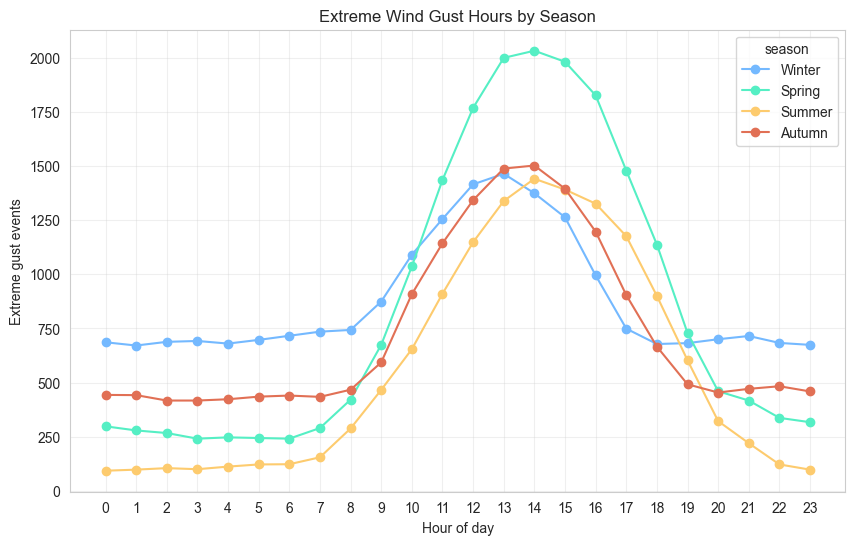

In [12]:
extreme = df[df['hour_windgust'] > 40]
pivot = extreme.pivot_table(index='hour', columns='season', aggfunc='size')
season_labels = {1: 'Winter', 2: 'Spring', 3: 'Summer', 4: 'Autumn'}
pivot = pivot.rename(columns=season_labels)
colors = ['#74b9ff', '#55efc4', '#fdcb6e', '#e17055']
pivot.plot(figsize=(10,6), marker='o', color=colors)
plt.xlabel('Hour of day')
plt.ylabel('Extreme gust events')
plt.title('Extreme Wind Gust Hours by Season')
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.show()

# Diurnal cycle in extreme wind activity across all seasons
Minimum activity occurs between **00:00 and 07:00**, followed by a sharp increase after **08:00**, peaking between **13:00 and 15:00**.
* **Spring**: Shows the highest overall peak due to significant thermal contrasts.
* **Winter** maintains the highest frequency of events during nighttime hours compared to other seasons and also has lower peak than **Spring**
* **Autumn** Shares a similar daytime amplitude with **Winter** but has less nighttime hours with extreme wind gust
* **Summer** records the lowest overall frequency, especially during the night

 # Hypothesis 4
Significant fluctuations in atmospheric pressure during the day usually indicate unstable weather conditions. Atmospheric pressure can act as an indicator of other atmospheric processes such as cyclones, anticyclones, weather changes, wind, and precipitation. Seasonal variations in atmospheric pressure may be associated with active weather processes that could theoretically influence the probability of an air raid alert occurring in a given region.

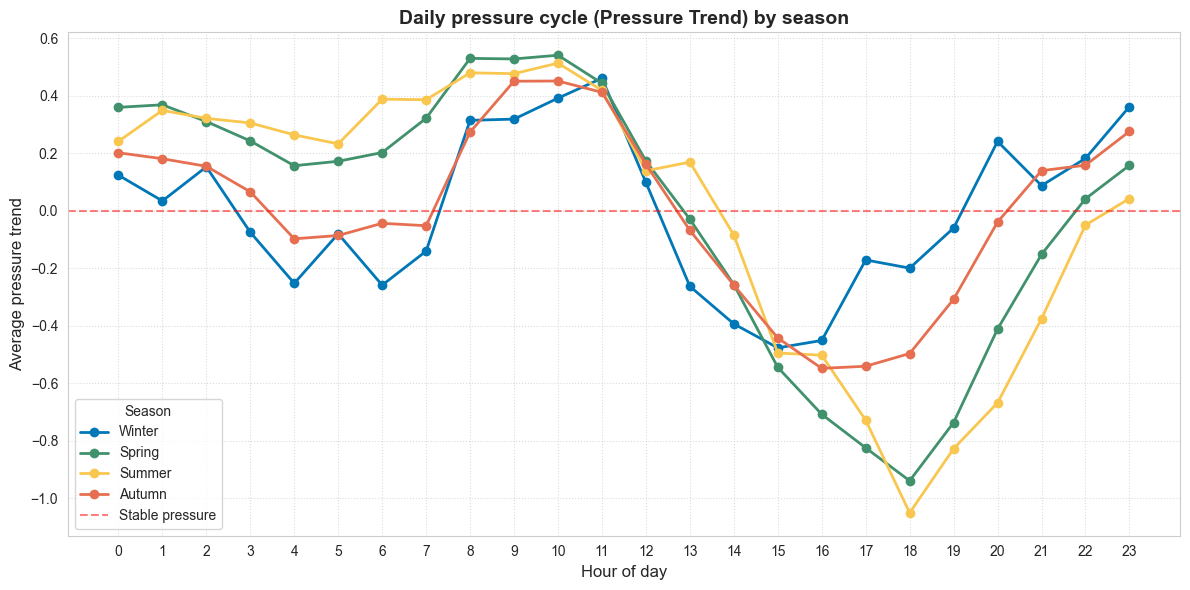

In [13]:
seasons = {1: 'Winter', 2: 'Spring', 3: 'Summer', 4: 'Autumn'}
df_pressure = (df.groupby(['season', 'hour'])['pressure_trend'].mean().unstack(level=0).rename(columns=seasons))
season_colors = {'Winter': '#0077b6', 'Spring': '#40916c', 'Summer': '#f9c74f', 'Autumn': '#e76f51'}
plt.figure(figsize=(12, 6))
for season in df_pressure.columns:
    plt.plot(df_pressure.index, df_pressure[season], marker='o', label=season, linewidth=2,      color=season_colors[season])
plt.axhline(0, color='red', linestyle='--', alpha=0.5, label='Stable pressure')
plt.title('Daily pressure cycle (Pressure Trend) by season', fontsize=14, fontweight='bold')
plt.xlabel('Hour of day', fontsize=12)
plt.ylabel('Average pressure trend', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(title='Season', fontsize=10)
plt.tight_layout()
plt.show()

#  Pressure Trend
### Night (00:00 - 03:00)
Pressure is actively rising in all seasons. **Spring** and **Summer** show the strongest rise.
### Early Morning (04:00 - 07:00)
The rate of rise slows, pressure begins falling, most sharply in **Winter**. Other seasons slow their rise but stay near zero.
### Morning (08:00 - 11:00)
Pressure switches to rapid rising again. The strongest positive trend of the day. It means pressure was rising fastest at these hours. **Spring** leads.
### Midday (12:00 - 14:00)
Pressure goes from rising to actively falling. All seasons cross the zero line between 12:00-14:00. This is the inflection point of the daily pressure cycle.
### Afternoon and Evening (15:00 - 18:00)
The most intense negative trend of the day. **Summer** hits −1.06 at 18:00, **Spring** -0.88. This is the period of most rapid pressure drop, typically associated with afternoon convection, thunderstorms, and low-pressure development. **Winter** and **Autumn** are less extreme (-0.47 to -0.57) due to weaker convective activity.
 ### Evening (19:00 - 23:00)
 The rate of falling slows down and pressure trend returns toward zero or positive, meaning pressure stops begins stabilizing and rising again. **Winter** shows the fastest pressure trend recovery. **Spring** and **Summer** recover slowly, suggesting pressure continues falling but at a diminishing rate.




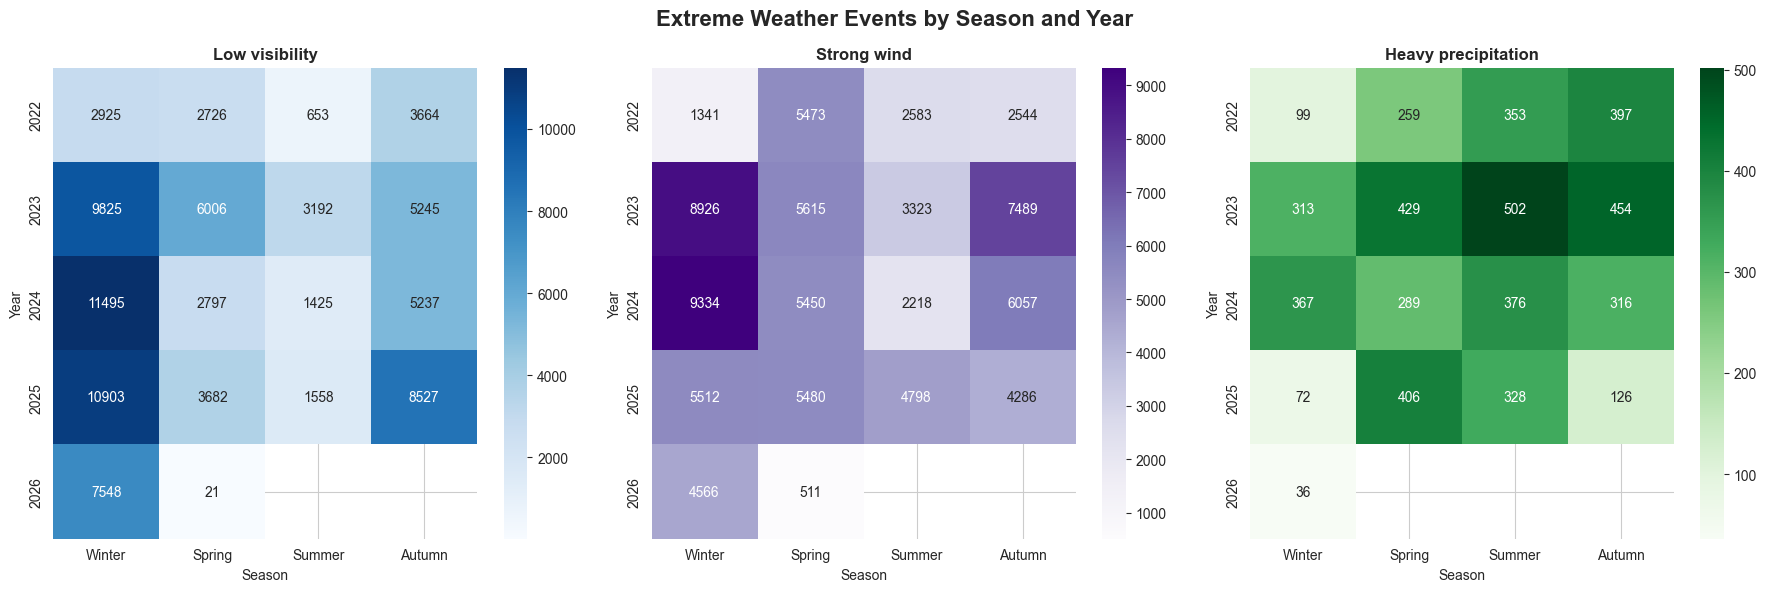

In [14]:
df['year'] = pd.to_datetime(df['day_datetime']).dt.year
conditions = {'Low visibility': df['hour_visibility'] < 5,
              'Strong wind': df['hour_windspeed'] > 20,
              'Heavy precipitation': df['hour_precip'] > 2}
cmaps = {'Low visibility': 'Blues', 'Strong wind': 'Purples', 'Heavy precipitation': 'Greens'}
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
season_labels = ['Winter', 'Spring', 'Summer', 'Autumn']
for ax, (title, condition) in zip(axes, conditions.items()):
    subset = df[condition]
    pivot = subset.pivot_table(index='year', columns='season', values='hour_temp', aggfunc='count')
    pivot = pivot[[1, 2, 3, 4]]
    sns.heatmap(pivot, cmap=cmaps[title], annot=True, fmt='g', ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Season')
    ax.set_ylabel('Year')
    ax.set_xticklabels(season_labels)
plt.suptitle('Extreme Weather Events by Season and Year', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Extreme weather events conclusion
* **Low Visibility**: This is the most frequent event type. It peaks significantly during **Winter**, with a sharp upward trend starting in 2023, reaching absolute peak of 11,495 in 2024. **Autumn** also shows high activity, while **Summer** consistently records the lowest occurrences.
* **Strong Wind**: There was a massive spike in **Winter** during 2023 and 2024 over 9,000 events. **Spring** remains a consistently high-risk season for wind across most years, **Autumn** demonstrates extreme volatility, **Summer** remains calm compared to other seasons.

* **Heavy Precipitation**: Compared to the low visibility and strong wind, the raw numbers are much lower, peaking around 500. The highest concentration is found in **Summer** and **Autumn**,**2023** saw relatively high levels across all seasons